# Model Training & Comparison

## Objective

This notebook trains and compares multiple machine-learning
algorithms for fake-news classification using the TF-IDF features
generated in Notebook 04.

The models evaluated are:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine
4. Random Forest

The models will be evaluated using accuracy, precision, recall,
F1-score, and ROC-AUC where applicable.

In [3]:
# import libraries
import pandas as pd
import joblib
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [4]:
df = pd.read_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/processed/further_cleaned_news.csv")

In [5]:
print(df.shape)
df.head()

(44680, 8)


,Unnamed: 0,title,text,subject,date,label,article_content,clean_text
0,0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,2016-11-16,1,It’s Really Happening: Trump Adviser Lays Out...,it’s really happening trump adviser lay plan n...
1,1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,2017-09-11,0,Republican attempt to deflect Trump-Russia pro...,republican attempt deflect trumprussia probe c...
2,2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,2017-09-09,0,Trump says churches should get FEMA funds for ...,trump say church get fema fund hurricane relie...
3,3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,2017-08-07,1,Trump Loves To Say The New York Times Is ‘Fai...,trump love say new york time ‘failing’ – effor...
4,4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,2017-03-24,0,House Speaker Ryan briefed Trump on healthcare...,house speaker ryan briefed trump healthcare bi...


In [6]:
df.isnull().sum()

Unnamed: 0         0
title              0
text               0
subject            0
date               1
label              0
article_content    0
clean_text         0
dtype: int64

In [7]:
# define X and Y
X = df["clean_text"]
y = df["label"]

In [8]:
print("Missing text:", X.isna().sum())

Missing text: 0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
# load the vectorizer
tfidf = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/tfidf_vectorizer.pkl")

In [11]:
print(tfidf)

TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)


In [12]:
# transfor training ad testing
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
# inspect everything
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (35744,)
X_test: (8936,)
X_train_tfidf: (35744, 50000)
X_test_tfidf: (8936, 50000)
y_train: (35744,)
y_test: (8936,)


In [14]:
X_train_tfidf.shape[1] == X_test_tfidf.shape[1]

True

In [15]:
# train logistic model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [16]:
# make prediction
lr_pred = lr_model.predict(X_test_tfidf)

In [17]:
lr_pred[:3]

array([0, 1, 0])

In [18]:
# Evaluste
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4242
           1       1.00      0.99      0.99      4694

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



In [19]:
print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.9926141450313339


In [20]:
# Multiniminal naive bayes model
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [21]:
# Evaluate
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4242
           1       0.97      0.97      0.97      4694

    accuracy                           0.97      8936
   macro avg       0.97      0.97      0.97      8936
weighted avg       0.97      0.97      0.97      8936



In [22]:
print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.9663160250671441


In [23]:
# Linear support vector machine
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)


In [24]:
# evaluate
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4242
           1       1.00      1.00      1.00      4694

    accuracy                           1.00      8936
   macro avg       1.00      1.00      1.00      8936
weighted avg       1.00      1.00      1.00      8936



In [25]:
print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.9976499552372426


In [26]:
# Randomforest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)


In [27]:
# evaluate
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4242
           1       1.00      1.00      1.00      4694

    accuracy                           1.00      8936
   macro avg       1.00      1.00      1.00      8936
weighted avg       1.00      1.00      1.00      8936



In [28]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9968666069829901


In [29]:
# create comparison table
results = []

models = {
    "Logistic Regression": (lr_model, lr_pred),
    "Naive Bayes": (nb_model, nb_pred),
    "Linear SVM": (svm_model, svm_pred),
    "Random Forest": (rf_model, rf_pred)
}

for name, (model, predictions) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.997650,0.998719,0.996804,0.997761
3,Random Forest,0.996867,0.997654,0.996378,0.997016
0,Logistic Regression,0.992614,0.995928,0.989987,0.992949
1,Naive Bayes,0.966316,0.969037,0.966766,0.967900


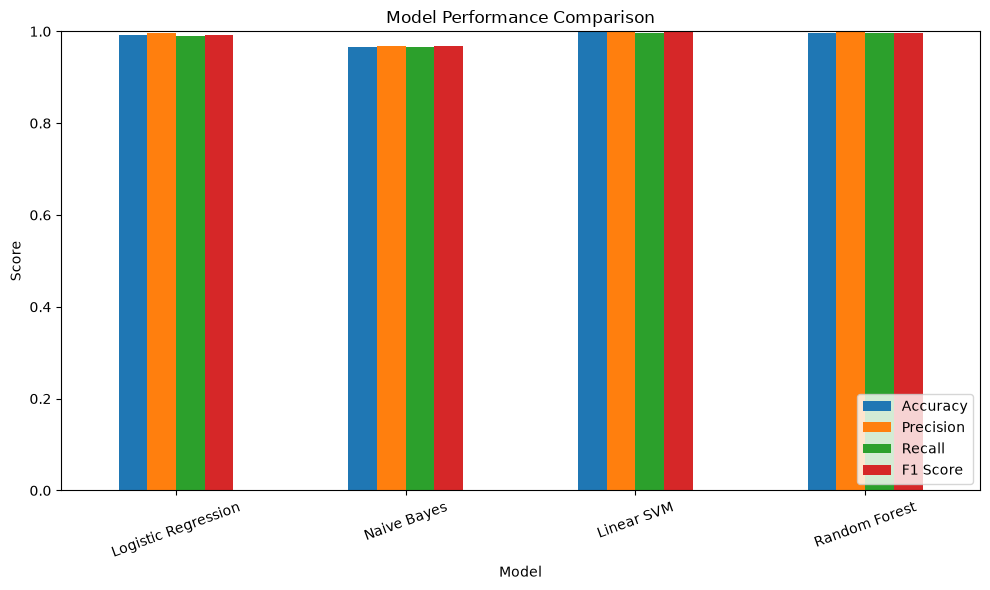

In [30]:
# plot performance
import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [31]:
# save the result
results_df.to_csv(
    "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/reports/model_comparison.csv",
    index=False
)

In [32]:
# save the model
import joblib

joblib.dump(lr_model, "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/logistic_regression.pkl")
joblib.dump(nb_model, "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/naive_bayes.pkl")
joblib.dump(svm_model, "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/linear_svm.pkl")
joblib.dump(rf_model, "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/random_forest.pkl")

['/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/random_forest.pkl']